Libraries Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
file_path = 'drugs.csv'
df = pd.read_csv(file_path)

display(df.head())

,Date,Drug_Name,Brand_Name,Strength,Opening_Stock,Received_Qty,Issued_Qty,Closing_Stock,Shortage_Flag,Lead_Time,USD_Rate
0,2020-01-01,Metformin,Glilcomet,500mg,500.0,4288.0,4084.0,704.0,0,7.0,181.3
1,2020-02-01,Metformin,Glilcomet,500mg,704.0,2888.0,2750.0,842.0,0,8.0,181.5
2,2020-03-01,Metformin,Glilcomet,500mg,842.0,3329.0,3170.0,1001.0,0,6.0,185.3
3,2020-04-01,Metformin,Glilcomet,500mg,1001.0,4293.0,4089.0,1205.0,0,9.0,192.5
4,2020-05-01,Metformin,Glilcomet,500mg,1205.0,4122.0,3926.0,1401.0,0,7.0,188.2


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2191 non-null   object 
 1   Drug_Name      2191 non-null   object 
 2   Brand_Name     2191 non-null   object 
 3   Strength       2191 non-null   object 
 4   Opening_Stock  2191 non-null   float64
 5   Received_Qty   2191 non-null   float64
 6   Issued_Qty     2191 non-null   float64
 7   Closing_Stock  2191 non-null   float64
 8   Shortage_Flag  2191 non-null   int64  
 9   Lead_Time      2191 non-null   float64
 10  USD_Rate       2191 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 188.4+ KB
None

Statistical Summary:


,Opening_Stock,Received_Qty,Issued_Qty,Closing_Stock,Shortage_Flag,Lead_Time,USD_Rate
count,2191.000000,2191.000000,2191.00000,2191.000000,2191.000000,2191.000000,2191.000000
mean,4299.739388,2739.209950,2660.04838,4374.253309,0.001826,10.669101,281.026184
std,5747.410239,3373.544639,3244.96519,5818.285473,0.042698,2.821566,67.135713
min,0.000000,0.000000,40.00000,0.000000,0.000000,0.000000,181.300000
25%,664.000000,422.500000,417.00000,688.000000,0.000000,9.000000,202.400000
50%,1508.000000,970.000000,950.00000,1548.000000,0.000000,11.000000,310.500000
75%,5897.500000,4665.000000,4542.00000,6083.500000,0.000000,12.000000,330.400000
max,33851.000000,33907.000000,32292.00000,35466.000000,1.000000,18.000000,368.200000


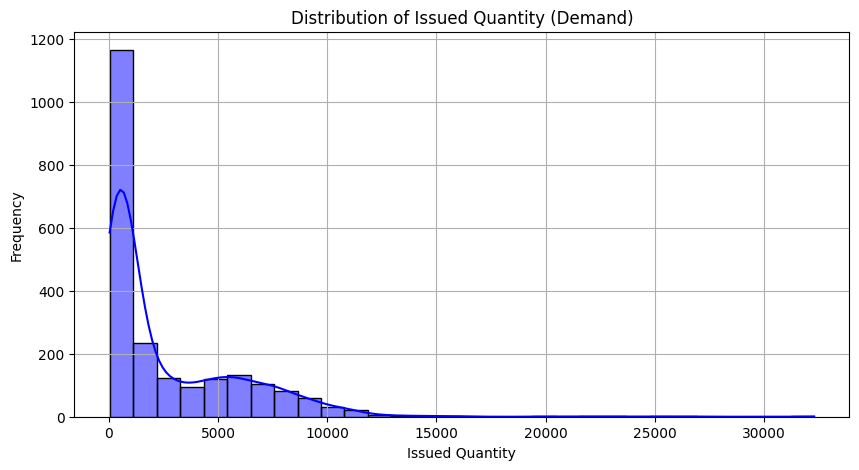

In [3]:
print("Dataset Info:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['Issued_Qty'].dropna(), bins=30, kde=True, color='blue')
plt.title('Distribution of Issued Quantity (Demand)')
plt.xlabel('Issued Quantity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [4]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df.fillna(0.0, inplace=True)

upper_limit = df['Issued_Qty'].quantile(0.99)
df['Issued_Qty'] = np.where(df['Issued_Qty'] > upper_limit, upper_limit, df['Issued_Qty'])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Date             0
Drug_Name        0
Brand_Name       0
Strength         0
Opening_Stock    0
Received_Qty     0
Issued_Qty       0
Closing_Stock    0
Shortage_Flag    0
Lead_Time        0
USD_Rate         0
dtype: int64

Missing values after cleaning:
Date             0
Drug_Name        0
Brand_Name       0
Strength         0
Opening_Stock    0
Received_Qty     0
Issued_Qty       0
Closing_Stock    0
Shortage_Flag    0
Lead_Time        0
USD_Rate         0
dtype: int64


In [5]:
df['Brand_Clean'] = df['Brand_Name'].astype(str).str.strip()

le = LabelEncoder()
df['Brand_Encoded'] = le.fit_transform(df['Brand_Clean'])

print("\nSample of Encoded Brands:")
display(df[['Brand_Clean', 'Brand_Encoded']].drop_duplicates().head())


Sample of Encoded Brands:


,Brand_Clean,Brand_Encoded
0,Glilcomet,13
73,Metfogen-XR,20
146,Glucopet-XR,14
219,Diamicron-MR,8
292,Diatica,9


In [6]:
scaler = MinMaxScaler()

num_cols = ['Opening_Stock', 'Received_Qty', 'Issued_Qty', 'Closing_Stock', 'USD_Rate', 'Lead_Time']

df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nData after Scaling (MinMaxScaler):")
display(df[num_cols].head())


Data after Scaling (MinMaxScaler):


,Opening_Stock,Received_Qty,Issued_Qty,Closing_Stock,USD_Rate,Lead_Time
0,0.014771,0.126464,0.353425,0.019850,0.000000,0.388889
1,0.020797,0.085174,0.236840,0.023741,0.001070,0.444444
2,0.024874,0.098180,0.273546,0.028224,0.021402,0.333333
3,0.029571,0.126611,0.353862,0.033976,0.059925,0.500000
4,0.035597,0.121568,0.339617,0.039503,0.036918,0.388889
